## Setup & Imports

In [23]:
import os
import torch
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import sys

sys.path.append(os.path.abspath(".."))

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Load DinoV2 Large (Vit-L/14) - Good balance of speed and power
# Note: This will download about 1.1GB of weights on the first run
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14').to(DEVICE)
dinov2.eval()
print(f"DinoV2 loaded on {DEVICE}")

Using cache found in /Users/zuzanna/.cache/torch/hub/facebookresearch_dinov2_main


DinoV2 loaded on mps


# Replica 

In [24]:
# 1. Paths
data_path = "../data/Replica/room_0/imap/00/"
rgb_path = os.path.join(data_path, "rgb/rgb_0.png")
depth_path = os.path.join(data_path, "depth/depth_0.png")

# 2. Load
rgb = plt.imread(rgb_path)
depth_raw = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)

if depth_raw is None:
    print(f"❌ Error: Could not load depth map at {depth_path}")
else:
    # --- THE FIX ---
    # Divide by 1000.0 because raw 5007 / 1000 = 5.007 meters (Correct for iMAP)
    depth_meters = depth_raw.astype(np.float32) / 1000.0

## Segment an object with SAM

In [ ]:
import open3d as o3d
from segment_anything import sam_model_registry, SamPredictor


# --- CONFIGURATION ---
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
CHECKPOINT = "../checkpoints/weights/sam_vit_h_4b8939.pth"
MODEL_TYPE = "vit_h"

# Replica Room_0 Intrinsics (from vMAP/iMAP configs)
# These are the "Lens Parameters" needed to un-distort pixels into 3D
INTRINSICS = {
    "fx": 600.0, "fy": 600.0,
    "cx": 599.5, "cy": 339.5
}

# 1. Initialize SAM on Mac GPU
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT).to(DEVICE)
predictor = SamPredictor(sam)

def get_3d_cloud(rgb, depth_meters, mask):
    """ Back-projects masked pixels into (X, Y, Z) space. """
    h, w = depth_meters.shape
    v, u = np.indices((h, w)) # Create pixel grid
    
    # Filter only the object pixels
    z = depth_meters[mask]
    u = u[mask]
    v = v[mask]
    
    # Pinhole Camera Math: $X = \frac{(u - c_x)Z}{f_x}$
    x = (u - INTRINSICS['cx']) * z / INTRINSICS['fx']
    y = (v - INTRINSICS['cy']) * z / INTRINSICS['fy']
    
    points = np.stack([x, y, z], axis=1)
    
    # Create Open3D Point Cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    
    # Optional: Get colors for the points
    colors = rgb[mask] / 255.0 if rgb.max() > 1.0 else rgb[mask]
    pcd.colors = o3d.utility.Vector3dVector(colors)
    
    return pcd

# --- EXECUTION ---
# Let's target the chair. In frame_0, a point on the chair is roughly (x=800, y=500)
input_point = np.array([[800, 500]]) 
input_label = np.array([1]) # 1 = foreground

predictor.set_image(rgb)
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

# Use the mask with the highest score
best_mask = masks[np.argmax(scores)]

# Convert to 3D
object_pcd_replica = get_3d_cloud(rgb, depth_meters, best_mask)

# Clean noise (essential for robotics data)
object_pcd_replica, _ = object_pcd_replica.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)

# Save it to check in MeshLab or visualize here
o3d.io.write_point_cloud("../assets/segmented_chair.pcd", object_pcd_replica)
print(f"✅ Success! Saved {len(object_pcd_replica.points)} points to ../assets/segmented_chair.pcd")

✅ Success! Saved 26894 points to ../assets/segmented_chair.pcd


In [ ]:
# See the point cloud in 3D
o3d.visualization.draw_geometries([object_pcd_replica], 
                                  window_name="SAM Segmented Object",
                                  width=800, height=600)

In [ ]:
# Check dimensions (for robotics, we care about real-world scale!)
bbox = object_pcd_replica.get_axis_aligned_bounding_box()
extent = bbox.get_extent()
print(f"Object Dimensions (meters): Width={extent[0]:.2f}, Height={extent[1]:.2f}, Depth={extent[2]:.2f}")

Object Dimensions (meters): Width=0.62, Height=0.59, Depth=0.47


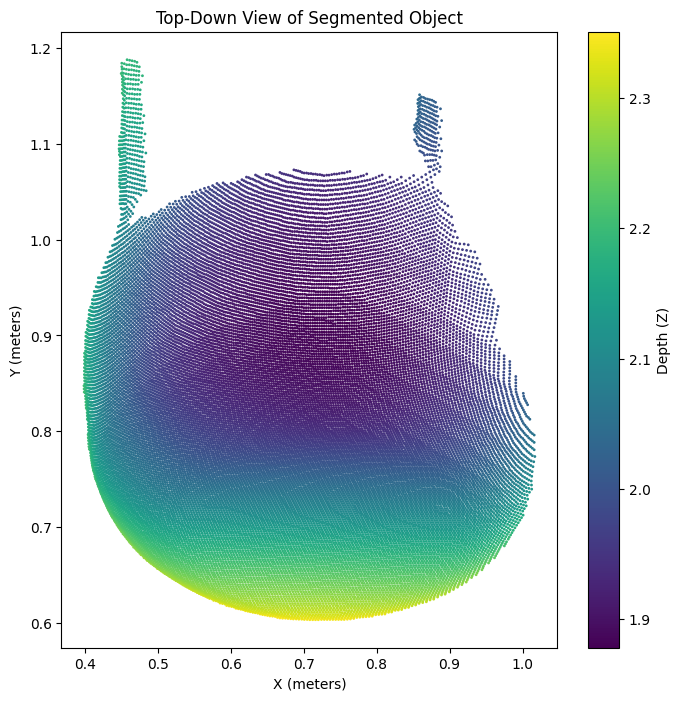

In [ ]:
# Plot the point cloud in 2D for a quick sanity check
points = np.asarray(object_pcd_replica.points)
plt.figure(figsize=(8, 8))
# Plot X and Y (Top down view if Z is depth)
plt.scatter(points[:, 0], points[:, 1], s=1, c=points[:, 2], cmap='viridis')
plt.colorbar(label="Depth (Z)")
plt.title("Top-Down View of Segmented Object")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.show()

# ScanNetPP

In [29]:
# 1. Paths
data_path = "../data/ScanNetPP/30966f4c6e/iphone/"
rgb_path = os.path.join(data_path, "rgb/frame_000000.jpg")
depth_path = os.path.join(data_path, "depth/frame_000000.png")

# 2. Load
rgb = plt.imread(rgb_path)
depth_raw = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED)

if depth_raw is None:
    print(f"❌ Error: Could not load depth map at {depth_path}")
else:
    # --- THE FIX ---
    # Divide by 1000.0 because raw 5007 / 1000 = 5.007 meters (Correct for iMAP)
    depth_meters = depth_raw.astype(np.float32) / 1000.0

## The Preprocessing Pipeline

DinoV2 expects 224×224 images. Since objects in ScanNet++ aren't square, the RGB image must be cropped based on the SAM mask (next step) and then resized.

In [30]:
# Function to crop the RGB image to the bounding box of the SAM mask
def get_object_crop(rgb_img, mask):
    """Crops the RGB image to the bounding box of the SAM mask."""
    y, x = np.where(mask)
    y1, y2, x1, x2 = y.min(), y.max(), x.min(), x.max()
    crop = rgb_img[y1:y2, x1:x2]
    return crop

# Standard ImageNet normalization used by DinoV2
transform = T.Compose([
    T.Resize(224, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

## Object Mask Generation

Generate the best object mask: run SAM (Segment Anything) on a specific pixel (specific location).
This step is essential the DinoV2 feature extraction.

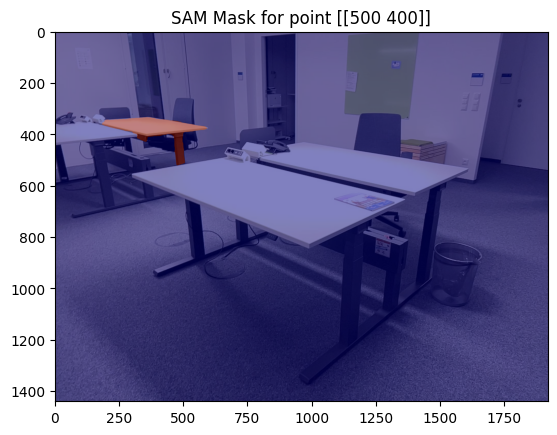

In [31]:
from segment_anything import sam_model_registry, SamPredictor

# 1. Initialize SAM (Assuming you have the weights from earlier)
SAM_CHECKPOINT = "../checkpoints/weights/sam_vit_h_4b8939.pth"
sam = sam_model_registry["vit_h"](checkpoint=SAM_CHECKPOINT).to(DEVICE)
predictor = SamPredictor(sam)

# 2. Tell SAM which image to look at
predictor.set_image((rgb * 255).astype(np.uint8) if rgb.max() <= 1.0 else rgb)

# 3. CHOOSE A POINT: Look at your RGB plot from the previous cell.
# Pick a coordinate (x, y) that lands on a piece of furniture.
# Example: x=500, y=400 (Adjust this based on your image!)
input_point = np.array([[500, 400]]) 
input_label = np.array([1]) # 1 means 'foreground'

# 4. Predict
masks, scores, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

# 5. Define best_mask
best_mask = masks[np.argmax(scores)]

# Visualize to confirm you caught the right object
plt.imshow(rgb)
plt.imshow(best_mask, alpha=0.5, cmap='jet')
plt.title(f"SAM Mask for point {input_point}")
plt.show()

In [37]:
# Function to convert SAM mask + depth into a 3D point cloud for ScanNet++ data

def get_3d_cloud(rgb, depth_meters, mask):
    # 1. Identify resolutions
    h_rgb, w_rgb = rgb.shape[:2]
    h_depth, w_depth = depth_meters.shape
    
    # 2. Resize mask to match DEPTH resolution
    # We use NEAREST to keep the mask binary (0 or 1)
    mask_small = cv2.resize(mask.astype(np.uint8), (w_depth, h_depth), 
                            interpolation=cv2.INTER_NEAREST).astype(bool)

    # 3. Scale Intrinsics (Calculates the ratio between RGB and Depth)
    # Focal lengths are defined in pixels, so they must shrink with the resolution
    ratio_h = h_depth / h_rgb
    ratio_w = w_depth / w_rgb
    
    fx = INTRINSICS['fx'] * ratio_w
    fy = INTRINSICS['fy'] * ratio_h
    cx = INTRINSICS['cx'] * ratio_w
    cy = INTRINSICS['cy'] * ratio_h

    # 4. Create the 3D points
    v, u = np.indices((h_depth, w_depth))
    z = depth_meters[mask_small]
    u_f = u[mask_small]
    v_f = v[mask_small]
    
    x = (u_f - cx) * z / fx
    y = (v_f - cy) * z / fy
    points = np.stack([x, y, z], axis=1)
    
    # 5. Handle Colors (Downsample RGB to match Depth)
    rgb_small = cv2.resize(rgb, (w_depth, h_depth), interpolation=cv2.INTER_LINEAR)
    
    # Cast to float32 immediately to allow decimal division
    colors = rgb_small[mask_small].astype(np.float32) 
    
    if colors.max() > 1.0: 
        colors /= 255.0  # This will now work perfectly

    # 6. Create Open3D Object
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    
    return pcd

In [ ]:
print(f"--- Resolution Check ---")
print(f"RGB:   {rgb.shape[:2]}")
print(f"Depth: {depth_meters.shape}")
print(f"Mask:  {best_mask.shape}")

# Now call the fixed function
object_pcd = get_3d_cloud(rgb, depth_meters, best_mask)

print(f"\n--- Point Cloud Check ---")
print(f"Number of points: {len(object_pcd_replica.points)}")

--- Resolution Check ---
RGB:   (1440, 1920)
Depth: (192, 256)
Mask:  (1440, 1920)

--- Point Cloud Check ---
Number of points: 422


In [ ]:
# Convert to 3D
object_pcd = get_3d_cloud(rgb, depth_meters, best_mask)

# Clean noise (essential for robotics data)
object_pcd, _ = object_pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)

# Save it to check in MeshLab or visualize here
o3d.io.write_point_cloud("../assets/segmented_table.pcd", object_pcd)
print(f"✅ Success! Saved {len(object_pcd.points)} points to ../assets/segmented_table.pcd")

# See the point cloud in 3D
o3d.visualization.draw_geometries([object_pcd], 
                                  window_name="SAM Segmented Object",
                                  width=800, height=600)

In [ ]:
# Check dimensions (for robotics, we care about real-world scale!)
bbox = object_pcd.get_axis_aligned_bounding_box()
extent = bbox.get_extent()
print(f"Object Dimensions (meters): Width={extent[0]:.2f}, Height={extent[1]:.2f}, Depth={extent[2]:.2f}")

Object Dimensions (meters): Width=3.00, Height=1.38, Depth=0.96


Text(0, 0.5, 'Y (meters)')

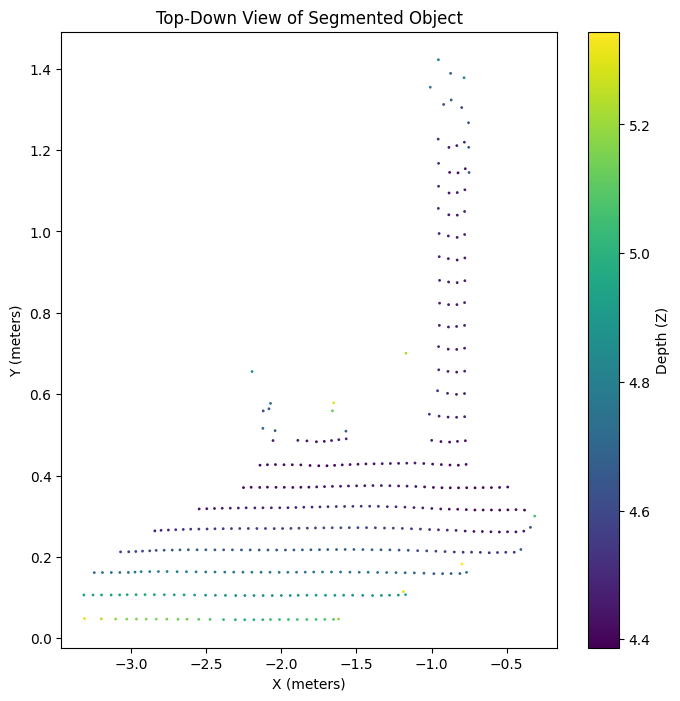

In [ ]:
# Plot the point cloud in 2D for a quick sanity check
points = np.asarray(object_pcd.points)
plt.figure(figsize=(8, 8))
# Plot X and Y (Top down view if Z is depth)
plt.scatter(points[:, 0], points[:, 1], s=1, c=points[:, 2], cmap='viridis')
plt.colorbar(label="Depth (Z)")
plt.title("Top-Down View of Segmented Object")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")

## Feature Extraction logic

This is where a picture is turned into a "semantic thought" (a vector).

In [ ]:
# 1. Get the crop from your ScanNet++ image and SAM mask
obj_crop = get_object_crop(rgb, best_mask) # Using your variables from Part 1
pil_img = Image.fromarray((obj_crop * 255).astype(np.uint8)) # Convert to PIL

# 2. Transform and move to Mac GPU
img_tensor = transform(pil_img).unsqueeze(0).to(DEVICE)

# 3. Inference
with torch.no_grad():
    # Global feature (CLS token)
    features = dinov2(img_tensor) 
    
print(f"Feature Vector Shape: {features.shape}") 
# Should be [1, 1024] for vitl14

Feature Vector Shape: torch.Size([1, 1024])


# Utonia - mock

In [ ]:
import torch
from core.utonia_backbone_copy import UtoniaBackbone

sys.path.append(os.path.abspath(".."))

# 1. Load Utonia (Switching to CPU/MPS for Mac)
utonia_device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
backbone = UtoniaBackbone(use_mock=False).to(utonia_device)

# Load your weights (ensure path is correct in your new repo)
# Use ".." to step out of the notebooks folder into the project root
checkpoint_path = "../checkpoints/utoniadreamer/latest.pth"

checkpoint = torch.load(checkpoint_path, map_location="cpu")
full_sd = checkpoint['model'] if 'model' in checkpoint else checkpoint
backbone_sd = {k.replace('backbone.', ''): v for k, v in full_sd.items() if k.startswith('backbone.')}
backbone.load_state_dict(backbone_sd, strict=False)
backbone.eval()

# 2. Preprocess Replica Point Cloud for Utonia
def prepare_for_utonia(pcd):
    points = np.asarray(pcd.points)
    
    # SHAPENET NORMALIZATION (Crucial!)
    # Center the object
    center = points.mean(axis=0)
    points -= center
    
    # Scale to fit unit sphere/box (Utonia expects roughly -0.5 to 0.5)
    max_dist = np.max(np.linalg.norm(points, axis=1))
    points /= (max_dist * 2.1) # Scale slightly smaller than the box
    
    return torch.from_numpy(points).float().unsqueeze(0).to(utonia_device), center, max_dist

# 3. Run Inference
input_tensor, obj_center, obj_scale = prepare_for_utonia(object_pcd_replica)

with torch.no_grad():
    # global_feat: Semantic 3D (similar to Dino but for geometry)
    # sparse_coords & point_feats: Detailed geometric features
    global_feat, (sparse_coords, point_feats) = backbone(input_tensor)

print(f"Utonia Global Feature Shape: {global_feat.shape}")
print(f"Utonia Point Features Shape: {point_feats.shape}")

⚠️ MOCK mode active
Utonia Global Feature Shape: torch.Size([1, 1024])
Utonia Point Features Shape: torch.Size([1, 1024])


💡 Visualization: Using Global/Mock color mode


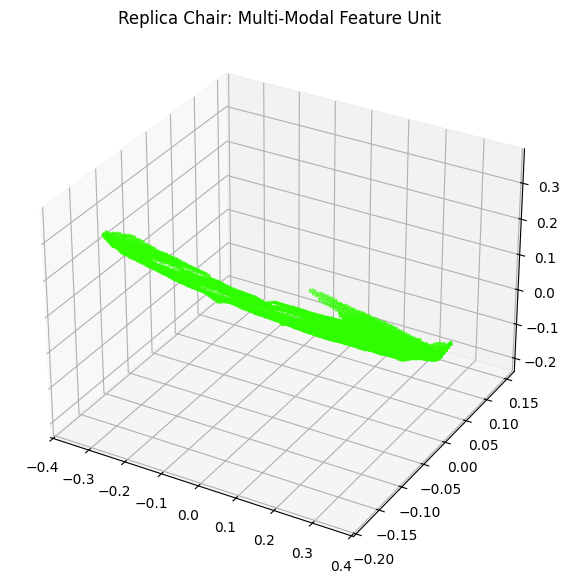

In [ ]:
from sklearn.decomposition import PCA
from scipy.spatial import KDTree

def visualize_scan_features(pcd, sparse_coords, point_feats):
    # 1. Prep Data
    full_pc = np.asarray(pcd.points)
    s_feats = point_feats.detach().cpu().numpy()
    
    # Force features to 2D
    if s_feats.ndim == 1:
        s_feats = s_feats.reshape(1, -1)

    # 2. Determine Color
    # If we have many points (Real Mode), use PCA
    if s_feats.shape[0] > 5:
        pca = PCA(n_components=3)
        pca_features = pca.fit_transform(s_feats)
        pca_min, pca_max = pca_features.min(axis=0), pca_features.max(axis=0)
        sparse_rgb = (pca_features - pca_min) / (pca_max - pca_min + 1e-8)
        
        # Interpolate using KDTree
        s_coords = sparse_coords.detach().cpu().numpy().reshape(-1, 3)
        tree = KDTree(s_coords)
        _, indices = tree.query(full_pc)
        full_rgb = sparse_rgb[indices]
    
    else:
        # MOCK/GLOBAL MODE: One color for the whole object
        print("💡 Visualization: Using Global/Mock color mode")
        # Generate a unique RGB based on the feature vector
        mock_color = np.array([
            np.mean(s_feats[:, 0:333]), 
            np.mean(s_feats[:, 333:666]), 
            np.mean(s_feats[:, 666:999])
        ])
        # Normalize to 0-1
        mock_color = (mock_color - mock_color.min()) / (mock_color.max() - mock_color.min() + 1e-8)
        full_rgb = np.tile(mock_color, (len(full_pc), 1))

    # 4. Plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(full_pc[:, 0], full_pc[:, 1], full_pc[:, 2], c=full_rgb, s=1, alpha=0.6)
    
    # Auto-scale the view to the chair
    ax.set_xlim(full_pc[:,0].min(), full_pc[:,0].max())
    ax.set_ylim(full_pc[:,1].min(), full_pc[:,1].max())
    ax.set_zlim(full_pc[:,2].min(), full_pc[:,2].max())
    
    ax.set_title("Replica Chair: Multi-Modal Feature Unit")
    plt.show()

visualize_scan_features(object_pcd_replica, sparse_coords, point_feats)